In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

np.random.seed(67)

### PCA

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
data = df[numeric_cols].copy().fillna(df[numeric_cols].mean())

X = data.values.astype(float)

In [4]:
# manual Z-score

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std = np.where(X_std == 0, 1, X_std)

Xs = (X - X_mean) / X_std

In [5]:
# covariance matrix

cov = np.cov(Xs.T)
cov

array([[ 1.0011236 ,  0.09166898, -0.23288596, -0.17939225, -0.33171106],
       [ 0.09166898,  1.0011236 ,  0.15983043,  0.21646789, -0.55011704],
       [-0.23288596,  0.15983043,  1.0011236 ,  0.41530381,  0.08317471],
       [-0.17939225,  0.21646789,  0.41530381,  1.0011236 ,  0.01846339],
       [-0.33171106, -0.55011704,  0.08317471,  0.01846339,  1.0011236 ]])

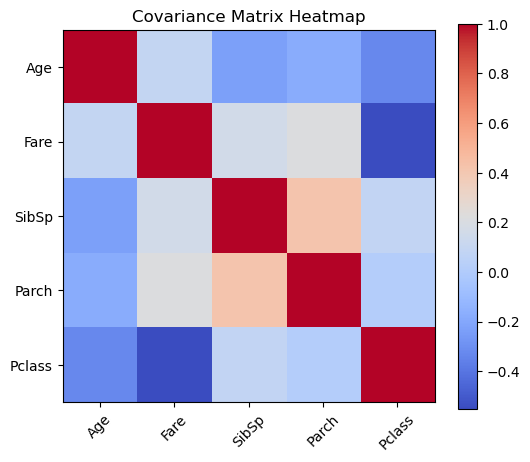

In [6]:
# plotting the covariance matrix heatmap

plt.figure(figsize=(6,5))
plt.imshow(cov, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Covariance Matrix Heatmap")
plt.show()

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = eigenvalues.argsort()[::-1] # sort in descending order

eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

explained_variance_ratio = eigenvalues_sorted / eigenvalues_sorted.sum()

eigenvalues_sorted, explained_variance_ratio

(array([1.69215967, 1.6317367 , 0.72538279, 0.58074859, 0.37559023]),
 array([0.3380521 , 0.32598107, 0.14491373, 0.11601936, 0.07503374]))

In [8]:
# projection on k components

k = 2
PCs = Xs @ eigenvectors_sorted[:, :k]

PCs[:10]

array([[ 1.15080251, -0.06919074],
       [-1.75860564,  0.14288499],
       [ 0.88943917, -0.71829878],
       [-1.44858089,  0.08172112],
       [ 0.57446002, -0.93901263],
       [ 0.75453206, -0.80543588],
       [-2.21094041, -0.95099444],
       [ 1.96434719,  2.40603486],
       [ 0.90680524,  0.81847023],
       [ 0.35747881,  0.36258153]])

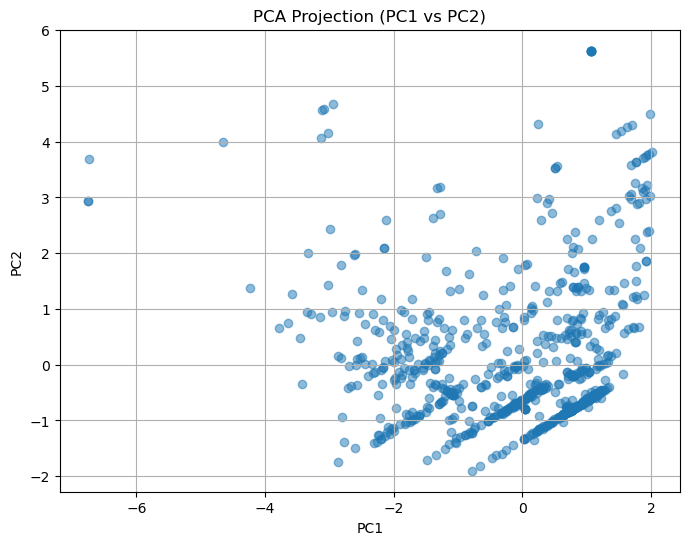

In [9]:
# plot of PC1 vs PC2

plt.figure(figsize=(8,6))
plt.scatter(PCs[:,0], PCs[:,1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.grid(True)
plt.show()

### SVM and Logistic Regression

In [10]:
y = df['Survived'].copy().values
y = np.where(y == 1, 1, -1)   # map to {-1, +1}

In [11]:
# train test split (80/20)

def train_test_split(X, y, test_size=0.2, shuffle=True, seed=67):
	n = X.shape[0]
	idx = np.arange(n)
	if shuffle:
		rng = np.random.RandomState(seed)
		rng.shuffle(idx)
	split = int(n * (1 - test_size))
	train_idx, test_idx = idx[:split], idx[split:]
	return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("train/test sizes:", X_train.shape[0], X_test.shape[0])

train/test sizes: 712 179


In [12]:
# standardize features

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std = np.where(std == 0, 1.0, std)

X_train_std = (X_train - mean) / std
X_test_std  = (X_test - mean)  / std

In [13]:
# linear SVM (hinge loss) implemented with mini-batch SGD

class LinearSVM:
	def __init__(self, lr=0.01, lambda_reg=1e-4, n_epochs=100, batch_size=32):
		self.lr = lr
		self.lambda_reg = lambda_reg
		self.n_epochs = n_epochs
		self.batch_size = batch_size

		self.w = None
		self.b = 0.0
	
	def _hinge_gradient(self, X_batch, y_batch):
		n = X_batch.shape[0]
		margins = y_batch * (X_batch.dot(self.w) + self.b)

		mask = margins < 1.0
		
		if mask.sum() == 0:
			grad_w = self.lambda_reg * self.w
			grad_b = 0.0
			return grad_w, grad_b
		
		X_m = X_batch[mask]
		y_m = y_batch[mask][:, np.newaxis]

		grad_hinge_w = - (X_m * y_m).mean(axis=0)
		grad_hinge_b = - (y_m.flatten()).mean()

		grad_w = self.lambda_reg * self.w + grad_hinge_w
		grad_b = grad_hinge_b

		return grad_w, grad_b
	
	def fit(self, X, y):
		n_samples, n_features = X.shape

		self.w = np.zeros(n_features, dtype=float)
		self.b = 0.0

		for epoch in range(1, self.n_epochs + 1):
			idx = np.arange(n_samples)
			np.random.shuffle(idx)
			X_shuffled = X[idx]
			y_shuffled = y[idx]

			# mini-batch SGD
			for start in range(0, n_samples, self.batch_size):
				end = start + self.batch_size
				X_batch = X_shuffled[start:end]
				y_batch = y_shuffled[start:end]

				grad_w, grad_b = self._hinge_gradient(X_batch, y_batch)

				# gradient
				self.w -= self.lr * grad_w
				self.b -= self.lr * grad_b
	
	def decision_function(self, X):
		return X.dot(self.w) + self.b
	
	def predict(self, X):
		scores = self.decision_function(X)
		return np.where(scores >= 0, 1, -1)

In [14]:
# logistic regression

class LogisticRegression:
	def __init__(self, lr=0.1, n_epochs=200, batch_size=None, lambda_reg=0.0):
		self.lr = lr
		self.n_epochs = n_epochs
		self.batch_size = batch_size
		self.lambda_reg = lambda_reg

		self.w = None
		self.b = 0.0

		self.history = {'loss': []}
	
	@staticmethod
	def _sigmoid(z):
		z = np.clip(z, -500, 500)
		return 1.0 / (1.0 + np.exp(-z))
	
	def _compute_loss(self, X, y):
		n = X.shape[0]
		logits = X.dot(self.w) + self.b
		probs = self._sigmoid(logits)

		eps = 1e-12
		probs = np.clip(probs, eps, 1 - eps)
		ce = -(y * np.log(probs) + (1 - y) * np.log(1 - probs)).mean()
		reg = 0.5 * self.lambda_reg * np.sum(self.w ** 2)

		return ce + reg
	
	def _gradients(self, X_batch, y_batch):
		n = X_batch.shape[0]
		logits = X_batch.dot(self.w) + self.b
		probs = self._sigmoid(logits)

		error = probs - y_batch
		dw = (X_batch.T @ error) / n
		db = error.mean()

		return dw, db
	
	def fit(self, X, y):
		n_samples, n_features = X.shape

		self.w = np.zeros(n_features, dtype=float)
		self.b = 0.0

		if self.batch_size is None: batch_size = n_samples
		else: batch_size = int(self.batch_size)

		for epoch in range(1, self.n_epochs + 1):
			perm = np.random.permutation(n_samples)
			X_shuf = X[perm]
			y_shuf = y[perm]

			# mini-batch
			for start in range(0, n_samples, batch_size):
				end = start + batch_size
				X_batch = X_shuf[start:end]
				y_batch = y_shuf[start:end]
				dw, db = self._gradients(X_batch, y_batch)

				self.w -= self.lr * dw
				self.b -= self.lr * db
			
			loss = self._compute_loss(X, y)
			self.history['loss'].append(loss)

	def predict_probability(self, X):
		logits = X.dot(self.w) + self.b
		return self._sigmoid(logits)
	
	def predict(self, X, threshold=0.5):
		return (self.predict_probability(X) >= threshold).astype(int)

In [15]:
# evaluate metrics

def metrics(y_true, y_pred):
	tp = ((y_true==1)&(y_pred==1)).sum()
	tn = ((y_true==0)&(y_pred==0)).sum()
	fp = ((y_true==0)&(y_pred==1)).sum()
	fn = ((y_true==1)&(y_pred==0)).sum()
	acc = (tp+tn) / len(y_true)
	prec = tp/(tp+fp) if(tp+fp)>0 else 0
	rec = tp/(tp+fn) if(tp+fn)>0 else 0
	f1 = 2*prec*rec/(prec+rec) if(prec+rec)>0 else 0
	return {"accuracy":acc,"precision":prec,"recall":rec,"f1":f1}

In [16]:
# training both models without PCA

logreg = LogisticRegression(lr=0.1, n_epochs=300, batch_size=32)
logreg.fit(X_train_std, y_train)
lr_pred_test = logreg.predict(X_test_std)

svm = LinearSVM(lr=0.01, lambda_reg=1e-3, n_epochs=200)
svm.fit(X_train_std, y_train)
svm_pred_test = svm.predict(X_test_std)

print("Logistic Regression (No PCA)", metrics(y_test, lr_pred_test))
print("SVM (No PCA)", metrics(y_test, svm_pred_test))

Logistic Regression (No PCA) {'accuracy': np.float64(0.0893854748603352), 'precision': np.float64(1.0), 'recall': np.float64(0.2222222222222222), 'f1': np.float64(0.3636363636363636)}
SVM (No PCA) {'accuracy': np.float64(0.2011173184357542), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0)}


In [17]:
# PCA fit on training data

k = 2

cov_train = np.cov(X_train_std.T)
eigvals_train, eigvecs_train = np.linalg.eig(cov_train)
idx_train = eigvals_train.argsort()[::-1]
eigvals_sorted_train = eigvals_train[idx_train]
eigvecs_sorted_train = eigvecs_train[:, idx_train]

explained_variance_ratio_train = eigvals_sorted_train / eigvals_sorted_train.sum()
print("Explained variance ratios (train):", explained_variance_ratio_train[:k])
print(f"Total explained by first {k} components: {explained_variance_ratio_train[:k].sum():.4f}")

X_train_pca = X_train_std @ eigvecs_sorted_train[:, :k]
X_test_pca  = X_test_std  @ eigvecs_sorted_train[:, :k]

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape :", X_test_pca.shape)

Explained variance ratios (train): [0.33532115 0.32510565]
Total explained by first 2 components: 0.6604
X_train_pca shape: (712, 2)
X_test_pca shape : (179, 2)


In [18]:
# train logistic regression on PCA features

logreg_pca = LogisticRegression(lr=0.1, n_epochs=300, batch_size=32, lambda_reg=0.0)
logreg_pca.fit(X_train_pca, (y_train == 1).astype(int))

lr_pca_pred_test = logreg_pca.predict(X_test_pca)

print("Logistic Regression (with PCA) metrics:", metrics((y_test==1).astype(int), lr_pca_pred_test))

Logistic Regression (with PCA) metrics: {'accuracy': np.float64(0.6927374301675978), 'precision': np.float64(0.717948717948718), 'recall': np.float64(0.3888888888888889), 'f1': np.float64(0.5045045045045045)}


In [19]:
# train SVM on PCA features

y_train_svm = np.where(y_train == 1, 1, -1)
y_test_svm  = np.where(y_test  == 1, 1, -1)

svm_pca = LinearSVM(lr=0.01, lambda_reg=1e-3, n_epochs=200, batch_size=32)
svm_pca.fit(X_train_pca, y_train_svm)

svm_pca_pred_test = svm_pca.predict(X_test_pca)
svm_pca_pred_test_bin = (svm_pca_pred_test == 1).astype(int)

print("SVM (with PCA) metrics:", metrics((y_test==1).astype(int), svm_pca_pred_test_bin))

SVM (with PCA) metrics: {'accuracy': np.float64(0.6871508379888268), 'precision': np.float64(0.7105263157894737), 'recall': np.float64(0.375), 'f1': np.float64(0.49090909090909096)}


In [20]:
try:
    svm_no_pca_pred_bin = (svm_pred_test == 1).astype(int)
except:
    svm_no_pca_pred_bin = (svm_pred_test == 1).astype(int)

summary = pd.DataFrame([
    ["Logistic (NO PCA)", metrics((y_test==1).astype(int), lr_pred_test)['accuracy']],
    ["SVM      (NO PCA)", metrics((y_test==1).astype(int), svm_no_pca_pred_bin)['accuracy']],
    ["Logistic (WITH PCA)", metrics((y_test==1).astype(int), lr_pca_pred_test)['accuracy']],
    ["SVM      (WITH PCA)", metrics((y_test==1).astype(int), svm_pca_pred_test_bin)['accuracy']],
], columns=["Model", "Accuracy"])

print(summary)

                 Model  Accuracy
0    Logistic (NO PCA)  0.675978
1    SVM      (NO PCA)  0.715084
2  Logistic (WITH PCA)  0.692737
3  SVM      (WITH PCA)  0.687151
